# Counterparty Credit Risk: CVA for an Interest Rate Swap

**Goal:** price the counterparty credit risk on a plain-vanilla interest rate swap — i.e., quantify how much value is at risk if the bank's counterparty defaults before the swap matures, and express that as a single number (CVA) that would be subtracted from the swap's "risk-free" price.

**Why this project:** it sits at the intersection of two areas that don't get covered by a standalone credit-scorecard project or a standalone options/VaR project — **derivative pricing** (valuing the swap itself under uncertain future rates) and **counterparty credit risk / XVA** (pricing in the chance the counterparty isn't there to pay). Nothing here needs an external dataset; it's a simulation exercise calibrated to one real market input (today's SOFR), the same way a trading desk would price CVA on a new deal using a model rather than historical data.

**Roadmap:**
1. Simulate future short-term interest rates (Vasicek model)
2. Price zero-coupon bonds analytically under Vasicek (needed to value the swap at every future point, for every simulated path)
3. Set up a plain-vanilla receive-fixed interest rate swap and compute its value along every simulated path
4. Build the counterparty **exposure profile** — Expected Exposure (EE) and Potential Future Exposure (PFE, 95th percentile)
5. Convert exposure into a single **CVA** number using a counterparty default (hazard rate) assumption
6. Stress-test counterparty credit quality



## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Vasicek Short-Rate Model — Simulating Future Interest Rates

The Vasicek short-rate model says the interest rate mean-reverts around a long-run level, with random shocks:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\,dW_t$$

- $r_0$: today's short rate — starting point for every simulated path
- $\kappa$: speed of mean reversion (how fast rates pull back toward $\theta$)
- $\theta$: long-run average short rate
- $\sigma$: short-rate volatility

**On the parameters — what's real data vs. an assumption (same discipline as the credit project):**
- $r_0 = 3.6\%$ — this is **real**: SOFR (the standard USD short-rate benchmark) was 3.62% as of Aug 13, 2026, per the NY Fed / FRED (`https://fred.stlouisfed.org/series/SOFR`). **Update this before you submit anything** — just check the current SOFR print and change `r0` below.
- $\theta = 3.8\%$, $\kappa = 0.5$, $\sigma = 1\%$ — these are **illustrative**, in the same spirit as your credit project's asset-correlation assumption: not fitted to a full historical rate series (that would need real data + a proper calibration routine), but reasonable, stated-as-such starting values. Worth saying exactly that if asked.

In [2]:
# ---- Vasicek short-rate parameters ----
r0    = 0.036   # today's short rate (SOFR, ~Aug 2026) -- update to current SOFR before submitting
kappa = 0.5     # speed of mean reversion
theta = 0.038   # long-run mean short rate (illustrative)
sigma = 0.01    # short-rate volatility (illustrative)

# ---- Simulation grid: 5-year swap, monthly steps ----
T = 5
dt = 1/12
n_steps = int(T/dt)
n_paths = 5000
time_grid = np.linspace(0, T, n_steps + 1)

# ---- Simulate short-rate paths (Euler-Maruyama discretization) ----
rates = np.zeros((n_paths, n_steps + 1))
rates[:, 0] = r0
Z = np.random.standard_normal((n_paths, n_steps))
for i in range(n_steps):
    rates[:, i+1] = rates[:, i] + kappa*(theta - rates[:, i])*dt + sigma*np.sqrt(dt)*Z[:, i]

print(f"Simulated {n_paths:,} short-rate paths over {T} years, {n_steps} monthly steps.")

Simulated 5,000 short-rate paths over 5 years, 60 monthly steps.


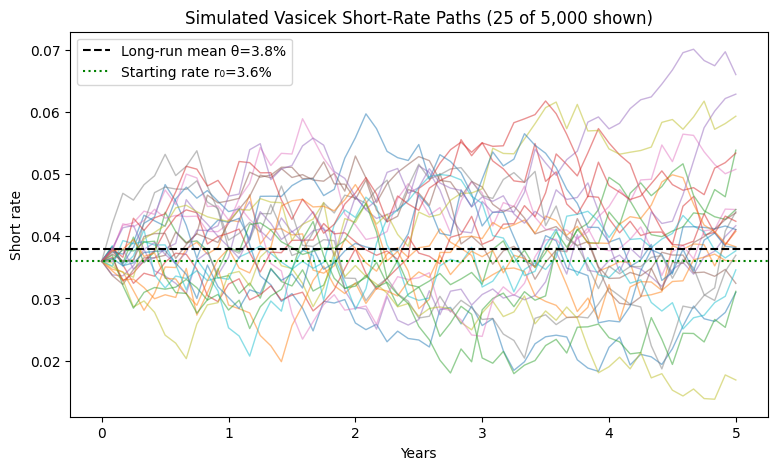

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
for p in range(25):
    ax.plot(time_grid, rates[p], alpha=0.5, lw=1)
ax.axhline(theta, color="black", ls="--", label=f"Long-run mean θ={theta:.1%}")
ax.axhline(r0, color="green", ls=":", label=f"Starting rate r₀={r0:.1%}")
ax.set_xlabel("Years"); ax.set_ylabel("Short rate")
ax.set_title("Simulated Vasicek Short-Rate Paths (25 of 5,000 shown)")
ax.legend()
plt.show()

## 3. Pricing Zero-Coupon Bonds Under Vasicek (closed form)

To value the swap at any future time $t$, for any simulated rate $r_t$, we need discount factors — i.e. the price today of \$1 received at a future date. Vasicek has a convenient **closed-form** zero-coupon bond price, so we don't need a second layer of simulation to get discount factors — just plug $r_t$ into a formula:

$$P(t,T) = A(t,T)\,e^{-B(t,T)\,r_t}$$

with $B(t,T) = \frac{1-e^{-\kappa(T-t)}}{\kappa}$ and $A(t,T)$ a (known, closed-form) function of $\kappa,\theta,\sigma$. This is the standard reason people like Vasicek for teaching/illustrative pricing — Black-Scholes for options is the equity-world analogue of "there's a clean formula, so you don't need to brute-force everything."

In [4]:
def vasicek_zcb(r, t, T, kappa, theta, sigma):
    """Price at time t of a zero-coupon bond maturing at T, given short rate r at time t.
    Works elementwise if r is an array (one value per simulated path)."""
    tau = T - t
    B = (1 - np.exp(-kappa*tau)) / kappa
    A = np.exp((theta - sigma**2/(2*kappa**2)) * (B - tau) - (sigma**2 * B**2)/(4*kappa))
    return A * np.exp(-B * r)

# sanity check: a bond maturing today (tau=0) should be worth exactly 1
print("Sanity check, P(t,t) should be 1.0:", vasicek_zcb(r0, 2.0, 2.0, kappa, theta, sigma))

Sanity check, P(t,t) should be 1.0: 1.0


## 4. The Swap: Set-Up and Valuation

**Instrument:** a plain-vanilla 5-year interest rate swap, notional \$10M, annual fixed payments. We take the bank's position as **receive-fixed / pay-floating** (economically similar to being long a bond).

**Why this decomposition works:** a vanilla swap's value is just (value of a fixed-rate bond) minus (value of a floating-rate bond), because:
- The **fixed leg** is worth $N \cdot K \cdot \sum_i \tau_i P(t,T_i)$ — literally a fixed-coupon bond.
- The **floating leg**, because it resets to par at every payment date, is always worth $N\cdot(1 - P(t,T_n))$ at any point between resets — a standard, textbook result, not something we need to simulate cashflow-by-cashflow.

We first find the **par swap rate** $K$ — the fixed rate that makes the swap worth \$0 at inception (how real swaps are actually quoted).

In [5]:
notional = 10_000_000
fixed_pay_times = np.arange(1, T + 1)   # annual fixed payments at t = 1, 2, 3, 4, 5
tau_fixed = 1.0                          # annual accrual

def par_swap_rate(t, r, fixed_times, kappa, theta, sigma):
    remaining = fixed_times[fixed_times > t]
    zcbs = np.array([vasicek_zcb(r, t, Ti, kappa, theta, sigma) for Ti in remaining])
    floating_leg = 1 - zcbs[-1]
    fixed_annuity = tau_fixed * zcbs.sum()
    return floating_leg / fixed_annuity

K = par_swap_rate(0, r0, fixed_pay_times, kappa, theta, sigma)
print(f"Par swap rate at inception: {K:.3%}")

Par swap rate at inception: 3.785%


In [6]:
def swap_value(t, r, K, fixed_times, notional, kappa, theta, sigma):
    """Value of a RECEIVE-FIXED swap to the bank, at time t, given short rate(s) r.
    r can be a scalar or an array (one value per simulated path)."""
    remaining = fixed_times[fixed_times > t]
    if len(remaining) == 0:
        return np.zeros_like(r)
    zcbs = np.array([vasicek_zcb(r, t, Ti, kappa, theta, sigma) for Ti in remaining])
    floating_leg_value = notional * (1 - zcbs[-1])
    fixed_leg_value = notional * K * tau_fixed * zcbs.sum(axis=0)
    return fixed_leg_value - floating_leg_value

# sanity check: at t=0, using r0, the swap should be worth ~$0 (that's the definition of the par rate)
print(f"Swap value at inception: ${swap_value(0, np.array([r0]), K, fixed_pay_times, notional, kappa, theta, sigma)[0]:,.2f}")

Swap value at inception: $0.00


## 5. Exposure Profile: Expected Exposure (EE) and Potential Future Exposure (PFE)

This is the core CCR concept. At any future date, the swap has some value to the bank — positive or negative, depending on which way rates have moved. **Exposure only exists on the side where we'd lose money if the counterparty defaults**: if the swap is negative to us (we owe them), their default doesn't cost us anything extra. So exposure at each date is $\max(\text{swap value}, 0)$, evaluated across every simulated path.

- **Expected Exposure (EE):** the *average* exposure across all paths, at each future date — the "typical" amount at risk.
- **Potential Future Exposure (PFE):** a high percentile (here, 95th) of exposure across paths — the "bad case" amount at risk, used for limit-setting in practice.

In [7]:
exposure = np.zeros((n_paths, n_steps + 1))
for i, t in enumerate(time_grid):
    r_t = rates[:, i]
    v = swap_value(t, r_t, K, fixed_pay_times, notional, kappa, theta, sigma)
    exposure[:, i] = np.maximum(v, 0)

EE = exposure.mean(axis=0)
PFE_95 = np.percentile(exposure, 95, axis=0)

print(f"Peak Expected Exposure:  ${EE.max():,.0f}  at t={time_grid[np.argmax(EE)]:.2f}y")
print(f"Peak 95% PFE:            ${PFE_95.max():,.0f}  at t={time_grid[np.argmax(PFE_95)]:.2f}y")

Peak Expected Exposure:  $345,876  at t=4.92y
Peak 95% PFE:            $571,852  at t=1.92y


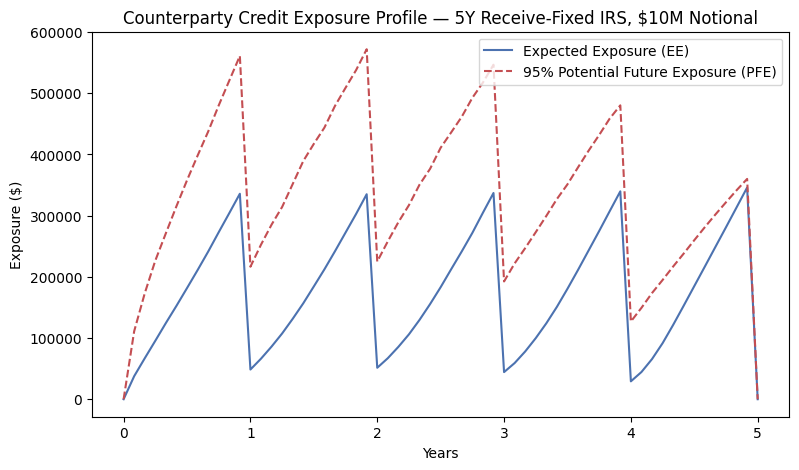

In [8]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(time_grid, EE, color="#4C72B0", label="Expected Exposure (EE)")
ax.plot(time_grid, PFE_95, color="#C44E52", ls="--", label="95% Potential Future Exposure (PFE)")
ax.set_xlabel("Years"); ax.set_ylabel("Exposure ($)")
ax.set_title("Counterparty Credit Exposure Profile — 5Y Receive-Fixed IRS, $10M Notional")
ax.legend()
plt.show()

**Reading the shape:** exposure here is low early on (little time has passed for rates to drift) and grows toward maturity, because our simplified floating-leg formula concentrates all its rate sensitivity in the final maturity discount factor rather than spreading it across each reset. A full production model (with a proper term-structure simulation, not the single-formula shortcut used here) usually produces a more **humped** profile — exposure rising then falling before maturity, since fewer cashflows remain to be at risk near the end. Worth stating this as an explicit simplification if asked — exactly the kind of "what would you change for a production model" question the JD's model-validation angle is built around.

## 6. From Exposure to CVA

**CVA (Credit Valuation Adjustment)** turns the exposure profile into a single dollar figure: the expected discounted loss from counterparty default, over the life of the trade.

$$\text{CVA} = (1-R)\sum_i EE(t_i)\cdot P(0,t_i)\cdot \big[S(t_{i-1}) - S(t_i)\big]$$

- $R$: recovery rate if the counterparty defaults (standard assumption: 40%, same convention used in most CDS/CVA textbook examples)
- $P(0,t_i)$: discount factor from today to $t_i$ (today's Vasicek curve — using the *current* rate curve to discount is standard; the *simulated* future rates are what generate the exposure, not the discounting)
- $S(t)=e^{-\lambda t}$: counterparty's survival probability to time $t$, under a **constant hazard rate** $\lambda$ — the simplest possible default-timing assumption (a full desk would bootstrap $\lambda$ from the counterparty's actual CDS curve; here we back it out from an illustrative credit spread, $\lambda \approx \text{spread}/(1-R)$, a standard rule-of-thumb approximation).

In [9]:
recovery_rate = 0.40
credit_spread = 0.015                      # 150bps -- illustrative "typical" counterparty
hazard_rate = credit_spread / (1 - recovery_rate)

discount = np.array([vasicek_zcb(r0, 0, t, kappa, theta, sigma) for t in time_grid])
survival = np.exp(-hazard_rate * time_grid)
marginal_pd = -np.diff(survival)            # default probability falling in each interval

CVA = (1 - recovery_rate) * np.sum(EE[1:] * discount[1:] * marginal_pd)
print(f"CVA estimate: ${CVA:,.0f}  ({CVA/notional:.3%} of notional)")

CVA estimate: $11,234  (0.112% of notional)


## 7. Stress-Testing Counterparty Credit Quality

Same instinct as the correlation stress test in the credit risk project: the counterparty's credit spread is the biggest, most uncertain lever here, so check how sensitive CVA is to it.

In [10]:
spread_scenarios = {
    "High-grade counterparty (50bps)":      0.005,
    "Typical counterparty (150bps)":        0.015,
    "Stressed / weak counterparty (400bps)": 0.04,
}

stress_results = {}
for label, spread in spread_scenarios.items():
    haz = spread / (1 - recovery_rate)
    surv = np.exp(-haz * time_grid)
    mpd = -np.diff(surv)
    cva = (1 - recovery_rate) * np.sum(EE[1:] * discount[1:] * mpd)
    stress_results[label] = cva

stress_df = pd.Series(stress_results, name="CVA ($)")
stress_df

,CVA ($)
High-grade counterparty (50bps),3902.293181
Typical counterparty (150bps),11233.507727
Stressed / weak counterparty (400bps),27085.240970


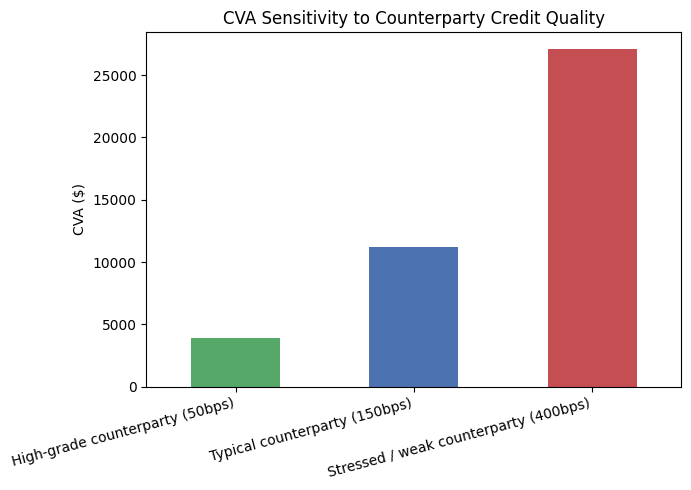

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
stress_df.plot(kind="bar", ax=ax, color=["#55A868","#4C72B0","#C44E52"])
ax.set_ylabel("CVA ($)")
ax.set_title("CVA Sensitivity to Counterparty Credit Quality")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Results Summary

| Metric | Value |
|---|---|
| Par swap rate at inception | 3.785% |
| Swap value at inception (sanity check) | \$0.00 |
| Peak Expected Exposure (EE) | \$345,876 at t=4.92y |
| Peak 95% Potential Future Exposure (PFE) | \$571,852 at t=1.92y |
| CVA — typical counterparty (150bps spread) | \$11,234 (0.112% of notional) |
| CVA — high-grade counterparty (50bps spread) | \$3,902 |
| CVA — stressed counterparty (400bps spread) | \$27,085 |
| CVA sensitivity, high-grade → stressed | ~6.9x increase |

**Reading these:** the swap starts at exactly \$0 (confirms the par rate is correct). Expected Exposure — the *typical* amount at risk — peaks near maturity at ~\$346K; the 95% PFE — the *bad-case* amount at risk — peaks earlier, around year 2, at ~\$572K (a tail scenario can spike before the "average" risk builds up, which is a legitimate and common pattern, not a bug). The headline CVA of ~\$11K for a \$10M notional swap is small in relative terms (0.11%), but it moves by nearly 7x purely from counterparty credit quality — the single biggest lever in this model, same role that asset correlation played in the credit-risk project's Economic Capital.

## 8. Summary & Wrap-Up

### What this notebook demonstrates
1. **Derivative pricing under uncertainty** — simulated future short rates with a Vasicek process and used the model's closed-form bond pricing formula to value a plain-vanilla interest rate swap at every future date, along every simulated path.
2. **Exposure quantification** — built Expected Exposure and 95% Potential Future Exposure profiles, the standard way counterparty risk is measured and limit-managed at a bank.
3. **Counterparty credit risk pricing (XVA)** — converted the exposure profile into a single CVA figure using a hazard-rate default model, calibrated to an illustrative credit spread.
4. **Sensitivity/stress testing** — quantified how CVA scales with counterparty credit quality (50bps → 400bps spread), the same "which assumption drives the number" discipline as the correlation stress test in the credit-risk project.

### Explicitly stated assumptions & limitations
- $\theta$, $\kappa$, $\sigma$ are illustrative, not fitted to a historical rate series or the current full yield curve; only $r_0$ is a real, current market input (today's SOFR).
- The floating leg is valued using the standard "resets to par" shortcut rather than simulating each individual reset explicitly — this is why the exposure profile here doesn't show the more realistic humped shape production models typically produce.
- Discounting for CVA uses today's curve; the exposure itself comes from the simulated future curve — this split is standard practice, not an inconsistency.
- The counterparty's default intensity is assumed constant over time and backed out from a single illustrative spread, rather than bootstrapped from an actual CDS term structure.
- No collateral, netting, or wrong-way risk (the possibility that counterparty default risk and swap exposure are correlated) is modeled — all of these are standard next steps in a production CVA model, and worth naming if asked "what would you add."